# 07 - 手写 BasicDDIM (MNIST)

> 配套笔记：[01_04 Diffusion（上）](https://github.com/Zoey-Cheng/MLSys-Learning-Notes/blob/main/notes/01_模型基础/01_04_Diffusion.md) ｜ 知乎：*WIP*

这个 demo 主要目的是把 **BasicDDIM 框架结构**跑通——§5.2 的 `ddim_sample`（`eta` + `steps` 旋钮覆盖 DDIM 和 DDPM 两种推理）。训练 loop 和 noise predictor 网络只是为了让 demo 端到端能跑，拼凑上去的占位实现；真正的工业 noise predictor 架构（U-Net 细节 / DiT / 文本条件注入）下篇才展开。

对照 doc §4 + §5.2 拼起来：

1. 加噪 schedule — `β / α / ᾱ` 全程预计算
2. 训练 loop（§4.1） — 抽 t、加噪、回归噪声（占位）
3. Noise predictor（§4.3） — 小 U-Net + sinusoidal time embedding（占位）
4. 端到端 MNIST — 训 10 epoch
5. **推理：DDIM 采样（§5.2）** — 主菜：`eta=0` 确定性 + `eta=1` 退回 DDPM 的对照

## 0. 环境

依赖只用 PyTorch + torchvision + matplotlib，单卡几分钟跑完。

In [1]:
!nvidia-smi 2>/dev/null | head -10 || echo 'no GPU; CPU 也能跑，只是慢一点'

Sat Jun 20 22:34:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |


In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torchvision import transforms

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


## 1. 加噪 schedule

调度预先算好（全程不变）：
- $\beta_t$ 线性从 1e-4 升到 0.02（DDPM 约定）
- $\alpha_t = 1 - \beta_t$
- $\bar\alpha_t = \prod_{s=1}^{t} \alpha_s$ —— 从 ≈1 单调降到 ≈0

训练 / 推理都靠这三个张量。

In [3]:
T = 1000
betas  = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
abar   = torch.cumprod(alphas, dim=0)

print(f'abar[0]   = {abar[0].item():.4f}   (t=0:     几乎纯图)')
print(f'abar[500] = {abar[500].item():.4f}   (t=500:   半噪)')
print(f'abar[T-1] = {abar[T-1].item():.6f}  (t=T-1:   ≈纯噪)')

def extract(a, t, shape):
    """取出 a[t]，reshape 成 [B, 1, 1, 1] 方便广播到 [B, C, H, W]。"""
    out = a.gather(-1, t)
    return out.view(shape[0], *([1] * (len(shape) - 1)))

abar[0]   = 0.9999   (t=0:     几乎纯图)
abar[500] = 0.0778   (t=500:   半噪)
abar[T-1] = 0.000040  (t=T-1:   ≈纯噪)


## 2. 训练 loop（§4.1）

三件事：抽 t、加噪、回归噪声。核心就这三行：

```
t   = torch.randint(0, T, (B,))         # 每张图独立随机一个时间步
eps = torch.randn_like(x0)              # GT 噪声
xt  = sqrt(abar[t]) * x0 + sqrt(1 - abar[t]) * eps
loss = MSE( model(xt, t), eps )
```

没有判别器、没有 KL —— 就是一个回归。DDPM-style 训练，下面 DDIM 推理直接复用。

In [4]:
def train_step(x0, model):
    """x0: [B, C, H, W]，干净图 (像素归一化到 [-1, 1])."""
    B = x0.size(0)
    t   = torch.randint(0, T, (B,), device=x0.device)
    eps = torch.randn_like(x0)

    # § 4.1: 一步到位加噪 (不迭代)
    a = extract(abar, t, x0.shape)
    xt = a.sqrt() * x0 + (1 - a).sqrt() * eps

    # 网络预测噪声 + MSE
    eps_pred = model(xt, t)
    return F.mse_loss(eps_pred, eps)

## 3. Noise predictor 网络（§4.3）

约束只有两条：
- 输入输出**同形状**（逐像素预测噪声）
- $t$ 要喂进去（先 sinusoidal 编码，再注入每一层）

满足这两条的网络都行。这里用 toy U-Net：28×28 → 14×14 → 7×7（中间）→ 14×14 → 28×28，skip 连接配 ResBlock，每层注入 time embedding。

下篇 LDM / DiT 都是直接换这个 noise predictor 网络，训练 / 采样逻辑不动。

In [5]:
class TimeEmbedding(nn.Module):
    """Sinusoidal time embedding (同 Transformer 的 PE)."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        args  = t[:, None].float() * freqs[None, :]
        return torch.cat([args.sin(), args.cos()], dim=-1)   # [B, dim]

In [6]:
class ResBlock(nn.Module):
    """GroupNorm + Conv + SiLU 两次，中间把 time embedding 加到 channel 上."""
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.norm1  = nn.GroupNorm(8, in_ch)
        self.conv1  = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2  = nn.GroupNorm(8, out_ch)
        self.conv2  = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.t_proj = nn.Linear(t_dim, out_ch)
        self.skip   = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.t_proj(F.silu(t_emb))[:, :, None, None]     # 注入 t
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)

In [7]:
class UNet(nn.Module):
    def __init__(self, base_ch=32, t_dim=128):
        super().__init__()
        self.t_mlp = nn.Sequential(
            TimeEmbedding(t_dim),
            nn.Linear(t_dim, t_dim), nn.SiLU(),
            nn.Linear(t_dim, t_dim),
        )
        # Down
        self.in_conv = nn.Conv2d(1, base_ch, 3, padding=1)
        self.down1   = ResBlock(base_ch,    base_ch * 2, t_dim)
        self.down2   = ResBlock(base_ch * 2, base_ch * 4, t_dim)
        # Mid
        self.mid     = ResBlock(base_ch * 4, base_ch * 4, t_dim)
        # Up (concat skip)
        self.up2     = ResBlock(base_ch * 4 + base_ch * 2, base_ch * 2, t_dim)
        self.up1     = ResBlock(base_ch * 2 + base_ch,     base_ch,     t_dim)
        # Out
        self.out_norm = nn.GroupNorm(8, base_ch)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_mlp(t)

        h0 = self.in_conv(x)                                          # 28x28, base
        h1 = self.down1(F.avg_pool2d(h0, 2), t_emb)                   # 14x14, 2*base
        h2 = self.down2(F.avg_pool2d(h1, 2), t_emb)                   # 7x7,   4*base
        m  = self.mid(h2, t_emb)                                      # 7x7,   4*base
        u2 = self.up2(torch.cat([F.interpolate(m,  scale_factor=2), h1], dim=1), t_emb)  # 14x14
        u1 = self.up1(torch.cat([F.interpolate(u2, scale_factor=2), h0], dim=1), t_emb)  # 28x28
        return self.out_conv(F.silu(self.out_norm(u1)))

model = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'#params: {n_params/1e6:.2f} M')

#params: 0.87 M


## 4. 端到端：MNIST 训练

把 MNIST 像素归一化到 $[-1, 1]$（跟模型预测的 $\epsilon \sim \mathcal N(0,1)$ 量级一致），训 10 个 epoch。loss 应该会从 epoch-1 的 ~0.09 收敛到 ~0.03。cell 顶上的 `%%time` 会自动打 wall time。

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2 - 1),     # [0, 1] -> [-1, 1]
])
ds = MNIST(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(ds, batch_size=128, shuffle=True, num_workers=2, drop_last=True)
print(f'#samples: {len(ds)}, #batches/epoch: {len(loader)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]

#samples: 60000, #batches/epoch: 468


In [9]:
%%time
EPOCHS = 10
opt = torch.optim.AdamW(model.parameters(), lr=2e-4)

model.train()
for epoch in range(EPOCHS):
    running = 0.0
    for x, _ in loader:
        x = x.to(device)
        loss = train_step(x, model)
        opt.zero_grad()
        loss.backward()
        opt.step()
        running += loss.item()
    print(f'epoch {epoch+1:02d}: avg loss = {running/len(loader):.4f}')

epoch 01: avg loss = 0.0865
epoch 02: avg loss = 0.0397
epoch 03: avg loss = 0.0351
epoch 04: avg loss = 0.0320
epoch 05: avg loss = 0.0306
epoch 06: avg loss = 0.0293
epoch 07: avg loss = 0.0290
epoch 08: avg loss = 0.0281
epoch 09: avg loss = 0.0275
epoch 10: avg loss = 0.0270
CPU times: user 2min 30s, sys: 2.58 s, total: 2min 33s
Wall time: 3min 2s


In [10]:
def show(samples, title=''):
    """samples: [N, 1, H, W] in [-1, 1]."""
    samples = samples.clamp(-1, 1).cpu().numpy()
    samples = (samples + 1) / 2                  # back to [0, 1]
    n = samples.shape[0]
    cols = min(n, 8)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
    axes = axes.flatten() if rows > 1 else ([axes] if cols == 1 else axes)
    for i, ax in enumerate(axes):
        if i < n:
            ax.imshow(samples[i, 0], cmap='gray')
        ax.axis('off')
    if title: fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## 5. 推理：DDIM 采样（§5.2）

**统一的采样器**，两个旋钮：
- `steps`：在 $\{0, \dots, T-1\}$ 里取子序列、跨步推理（doc §5 的「采样路径压缩」）
- `eta`：随机性。`eta=0` 确定性 DDIM；`eta=1` + `steps=T` 退回原始 DDPM 反向（doc §4.2 公式）

每一步两段走：(a) 反解 $\hat x_0$；(b) 用加噪公式合成 $x_{t'}$。

In [11]:
@torch.no_grad()
def ddim_sample(model, shape, steps=50, eta=0.0):
    """统一采样器：eta + steps 旋钮覆盖 DDIM / DDPM 两种推理."""
    model.eval()
    # 在 [0, T-1] 里取 steps 个时刻，由大到小
    seq = torch.linspace(T - 1, 0, steps, device=device).long()
    x = torch.randn(shape, device=device)

    for i in range(len(seq)):
        t  = seq[i].item()
        tp = seq[i + 1].item() if i + 1 < len(seq) else -1
        t_batch = torch.full((shape[0],), t, device=device, dtype=torch.long)

        eps     = model(x, t_batch)
        a_t     = abar[t]
        a_prev  = abar[tp] if tp >= 0 else torch.tensor(1.0, device=device)

        # (a) 反解 x_0
        x0_pred = (x - (1 - a_t).sqrt() * eps) / a_t.sqrt()
        # (b) 合成 x_{t'}; eta 控制随机性
        sigma   = eta * ((1 - a_prev) / (1 - a_t)).sqrt() * (1 - a_t / a_prev).sqrt()
        noise   = torch.randn_like(x) if eta > 0 and tp >= 0 else torch.zeros_like(x)
        x = a_prev.sqrt() * x0_pred + (1 - a_prev - sigma ** 2).clamp(min=0).sqrt() * eps + sigma * noise

    model.train()
    return x

/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 40664 (\N{CJK UNIFIED IDEOGRAPH-9ED8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 35748 (\N{CJK UNIFIED IDEOGRAPH-8BA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38469 (\N{CJK UNIFIED IDEOGRAPH-9645}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

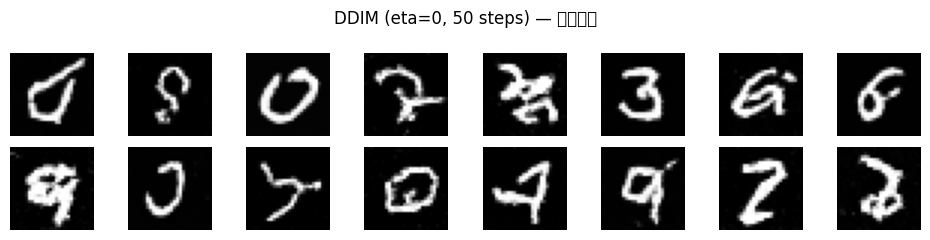

In [12]:
# 默认 DDIM: 50 步, 确定性
samples = ddim_sample(model, (16, 1, 28, 28), steps=50, eta=0.0)
show(samples, title='DDIM (eta=0, 50 steps) — 实际默认')

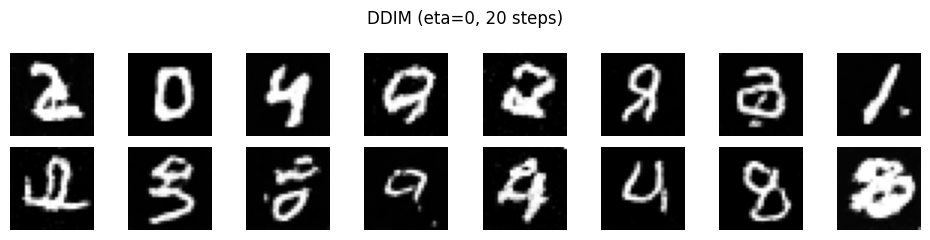

In [13]:
# 更激进的压缩
samples = ddim_sample(model, (16, 1, 28, 28), steps=20, eta=0.0)
show(samples, title='DDIM (eta=0, 20 steps)')

/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 21453 (\N{CJK UNIFIED IDEOGRAPH-53CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2710/2623874726.py:15: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(

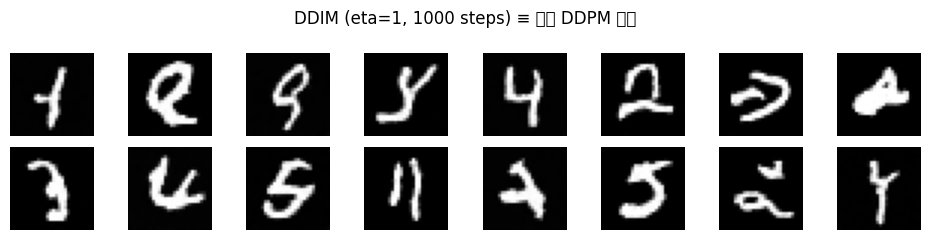

In [14]:
# DDPM = DDIM 的 eta=1 + steps=T 特例（慢一个数量级，对照用）
samples = ddim_sample(model, (16, 1, 28, 28), steps=T, eta=1.0)
show(samples, title='DDIM (eta=1, 1000 steps) ≡ 原始 DDPM 反向')

---

**BasicDDIM 框架核就这么大**：
- §2 训练 = 3 行（抽 t、加噪、回归）—— 占位，跟 DDPM 一样
- §3 网络 = 「同分辨率 + 喂 t」的任意 CNN —— toy U-Net，下篇换 DiT 或工业 U-Net 都行
- §5 推理 = 一个 `ddim_sample` 函数，`eta + steps` 覆盖 DDIM / DDPM 两种推理 —— 这才是这个 demo 的主轴

下篇 LDM / DiT / Flow Matching 全是「这个框架 + 一处增量」，配套 ipynb 后续补。